# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
expressão_genes = np.random.normal(size=1000)
print(expressão_genes[:10])

def up_or_down(array):
    resultado = np.where(array > 0, "Up", "Down")
    return resultado
resultado = up_or_down(expressão_genes)
print(resultado[:10])


[ 1.47107167  0.38413736 -0.55815128  0.15843835 -0.82197489 -0.28784191
 -1.14530125  1.10228436  0.02601007 -0.59042628]
['Up' 'Up' 'Down' 'Up' 'Down' 'Down' 'Down' 'Up' 'Up' 'Down']


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
número_de_genes = np.random.randint(0,1000,size=1000)
print(número_de_genes[:10])
indices = [f"Paciente {i}" for i in range(1, 1001)]
Genes = pd.DataFrame({
    "expressão_genes": expressão_genes,
    "número_de_genes": número_de_genes
}, index=indices)
print(Genes.head())

[925 364 223 319 130 649 572 876  79 795]
            expressão_genes  número_de_genes
Paciente 1         1.471072              925
Paciente 2         0.384137              364
Paciente 3        -0.558151              223
Paciente 4         0.158438              319
Paciente 5        -0.821975              130


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados foram categorizados com base na expressão_genes sendo que sendo a primeira categoria continha genes com expressao_genes menor que -10, a segunda de -10 a -5, a terceira de -5 a 0, a quarta com genes de 0 a 5, a quinta de 5 a 10 e a sexta continha genes com expressão superior a 10.

In [ ]:
def categorizar(valor):
    if valor < -10:
        return "< -10"
    elif -10 <= valor < -5:
        return "-10 a -5"
    elif -5 <= valor < 0:
        return "-5 a 0"
    elif 0 <= valor < 5:
        return "0 a 5"
    elif 5 <= valor < 10:
        return "5 a 10"
    else:
        return "> 10"
Genes["categoria_expressão"] = Genes["expressão_genes"].apply(categorizar)
print(Genes.head())

            expressão_genes  número_de_genes categoria_expressão  \
Paciente 1         1.471072              925               0 a 5   
Paciente 2         0.384137              364               0 a 5   
Paciente 3        -0.558151              223              -5 a 0   
Paciente 4         0.158438              319               0 a 5   
Paciente 5        -0.821975              130              -5 a 0   

            freq_expressão_genes  freq_número_de_genes  \
Paciente 1                     1                     3   
Paciente 2                     1                     2   
Paciente 3                     1                     1   
Paciente 4                     1                     1   
Paciente 5                     1                     1   

            freq_categoria_expressão                 Categorias  
Paciente 1                       487                   Aumentou  
Paciente 2                       487  Quase sem efeito positivo  
Paciente 3                       513  Quase 

## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [5]:
def freq_simples(df):
    df_resultado = df.copy()
    
    for col in df.columns:
            freq = df[col].value_counts()
            df_resultado[f"freq_{col}"] = df[col].map(freq)
    
    return df_resultado
Genes = Genes[[col for col in Genes.columns if not col.startswith("freq_")]]
Genes = freq_simples(Genes)
print(Genes.head())

            expressão_genes  número_de_genes categoria_expressão  \
Paciente 1         1.471072              925               0 a 5   
Paciente 2         0.384137              364               0 a 5   
Paciente 3        -0.558151              223              -5 a 0   
Paciente 4         0.158438              319               0 a 5   
Paciente 5        -0.821975              130              -5 a 0   

            freq_expressão_genes  freq_número_de_genes  \
Paciente 1                     1                     3   
Paciente 2                     1                     2   
Paciente 3                     1                     1   
Paciente 4                     1                     1   
Paciente 5                     1                     1   

            freq_categoria_expressão  
Paciente 1                       487  
Paciente 2                       487  
Paciente 3                       513  
Paciente 4                       487  
Paciente 5                       513  


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [6]:
# grafico = Genes["culuna"].head(40)
# grafico.plot(kind="bar", figsize=(10,5))
# plt.title("Frequências por paciente")
# plt.xlabel("Pacientes")
# plt.ylabel("Frequência")
# plt.xticks(rotation=45)
# plt.legend()
# plt.show()

# grafico.plot(kind="line", marker='o', figsize=(10,5))
# plt.title("Frequências por paciente")
# plt.xlabel("Pacientes")
# plt.ylabel("Frequência")
# plt.xticks(rotation=45)
# plt.legend()
# plt.show()

### Expressão

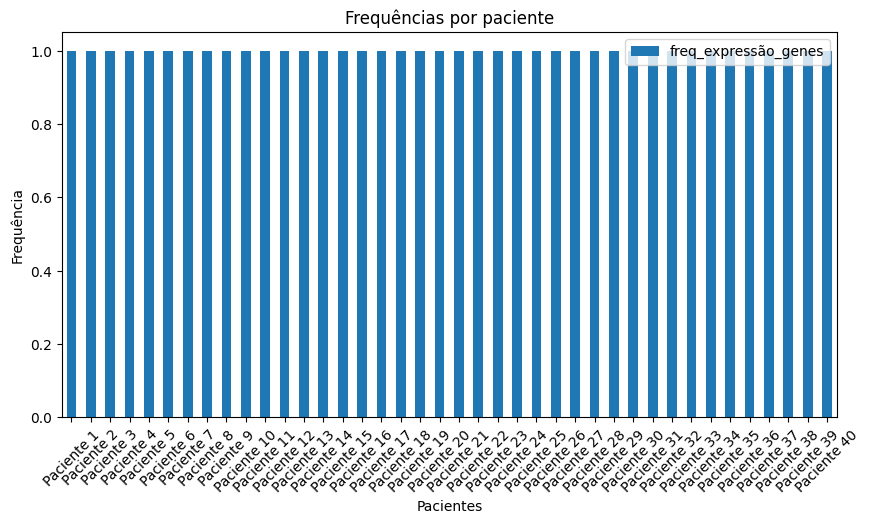

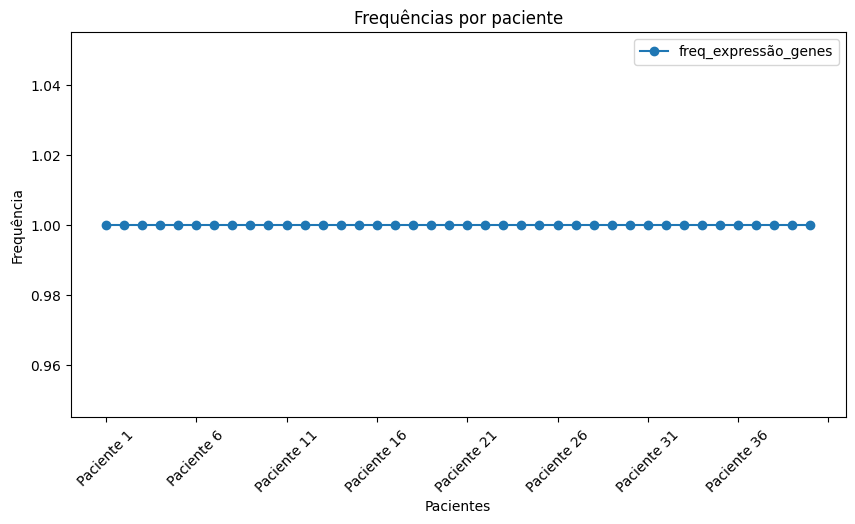

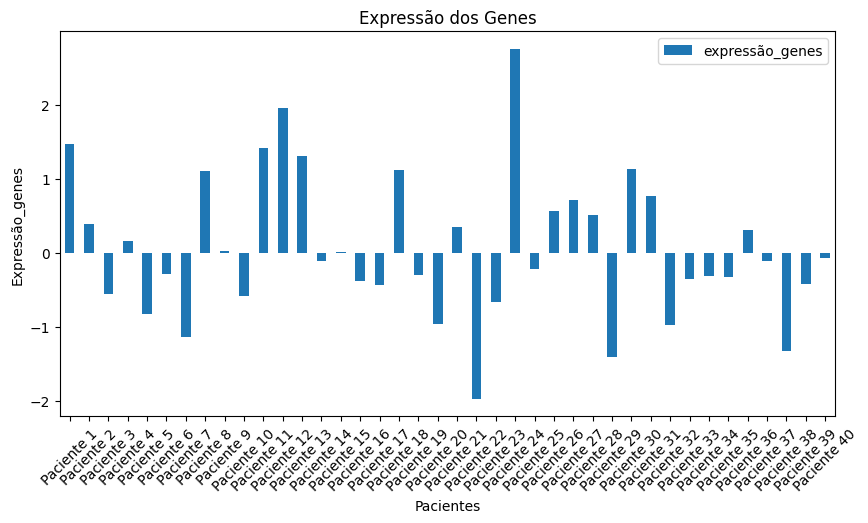

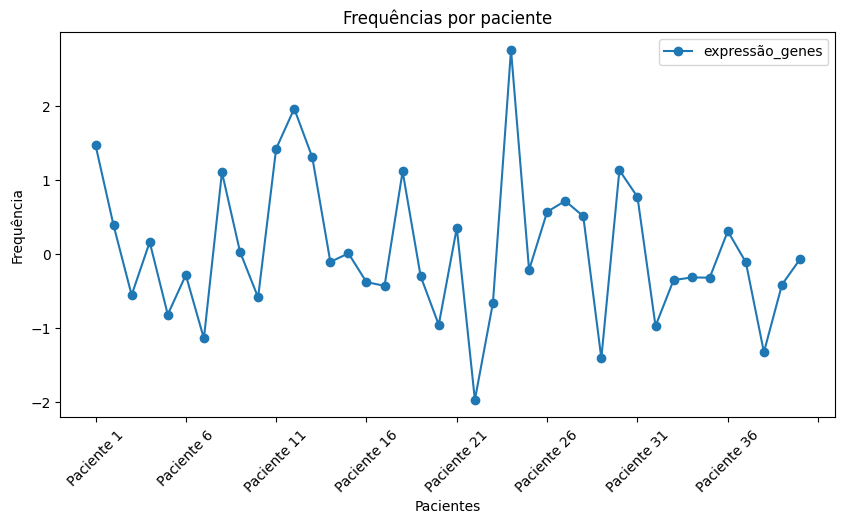

In [7]:
p_grafico = Genes["freq_expressão_genes"].head(40)
p_grafico.plot(kind="bar", figsize=(10,5))
plt.title("Frequências por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico.plot(kind="line", marker='o', figsize=(10,5))
plt.title("Frequências por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico2 = Genes["expressão_genes"].head(40)
p_grafico2.plot(kind="bar", figsize=(10,5))
plt.title("Expressão dos Genes")
plt.xlabel("Pacientes")
plt.ylabel("Expressão_genes")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico2.plot(kind="line", marker='o', figsize=(10,5))
plt.title("Frequências por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()


### Número

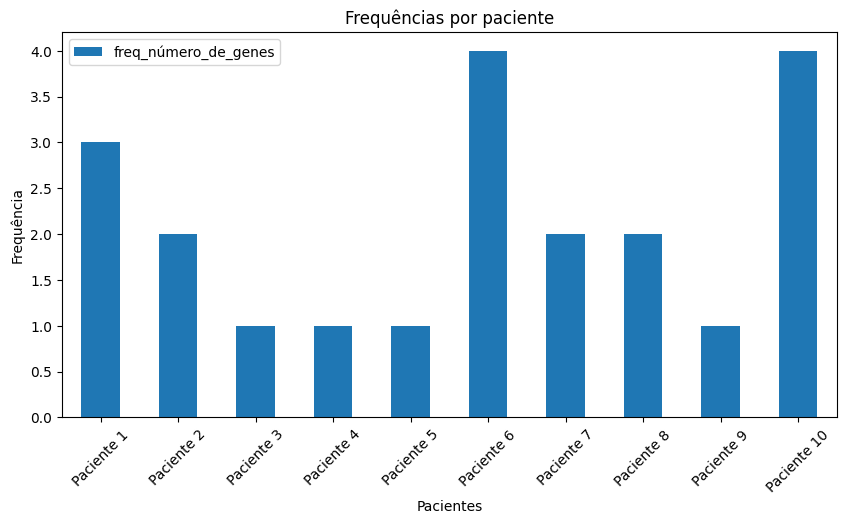

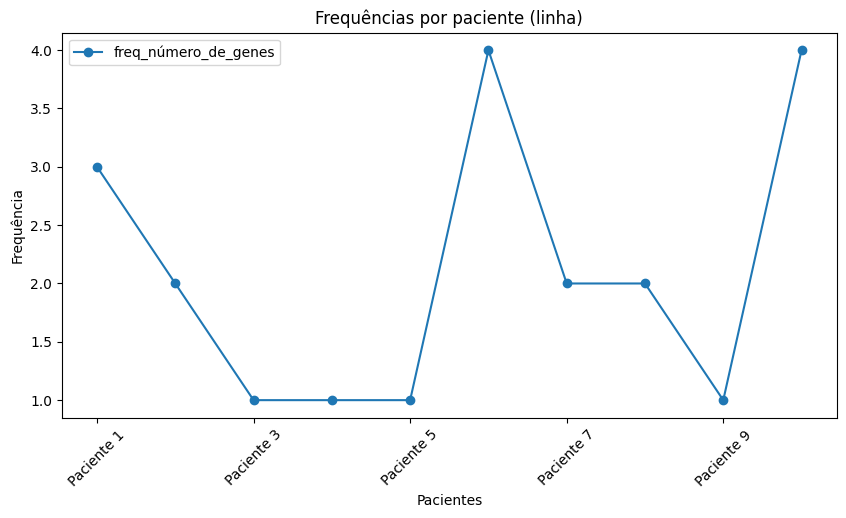

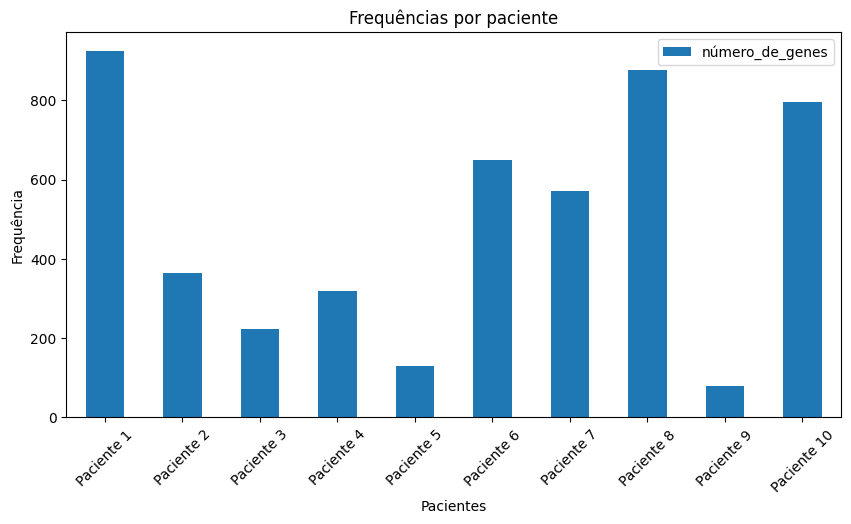

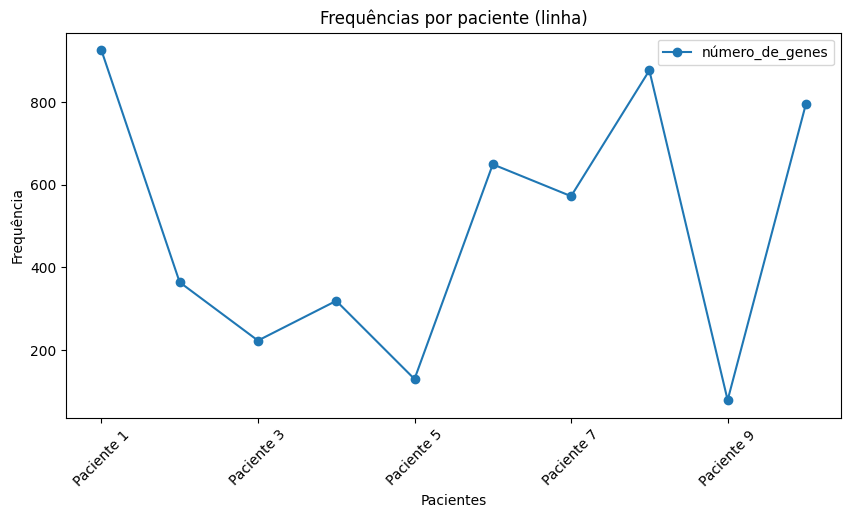

In [8]:
p_grafico = Genes[[
    "freq_número_de_genes",
]].head(10)
p_grafico.plot(kind="bar", figsize=(10,5))
plt.title("Frequências por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico.plot(kind="line", marker='o', figsize=(10,5))
plt.title("Frequências por paciente (linha)")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico2 = Genes[[
    "número_de_genes",
]].head(10)
p_grafico2.plot(kind="bar", figsize=(10,5))
plt.title("Frequências por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

p_grafico2.plot(kind="line", marker='o', figsize=(10,5))
plt.title("Frequências por paciente (linha)")
plt.xlabel("Pacientes")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

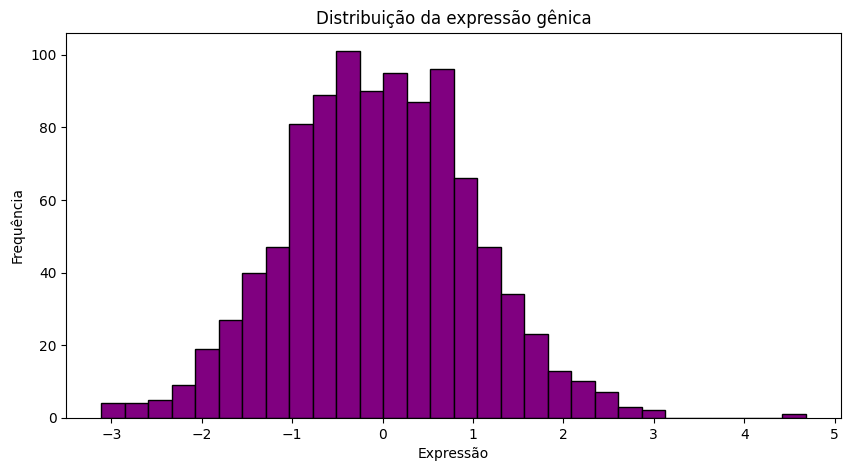

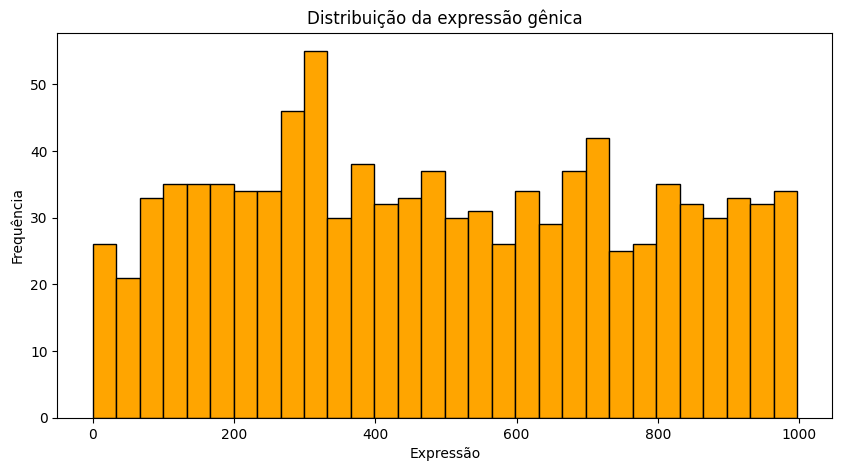

In [13]:
plt.figure(figsize=(10,5))
plt.hist(Genes["expressão_genes"], bins=30, color="purple", edgecolor="black")
plt.title("Distribuição da expressão gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(Genes["número_de_genes"], bins=30, color="orange", edgecolor="black")
plt.title("Distribuição da expressão gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

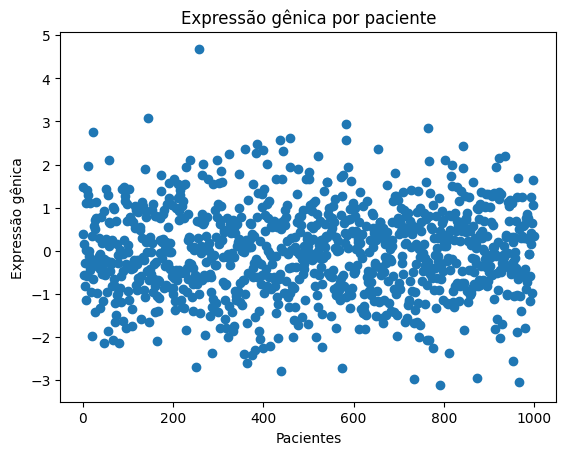

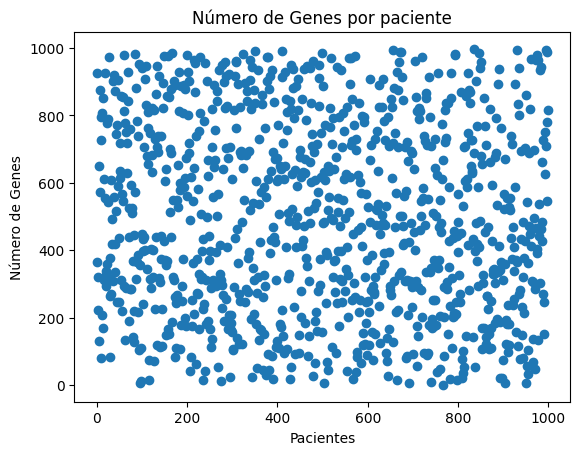

In [10]:
plt.scatter(range(len(Genes)),Genes["expressão_genes"])
plt.title("Expressão gênica por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Expressão gênica")
plt.show()


plt.scatter(range(len(Genes)),Genes["número_de_genes"])
plt.title("Número de Genes por paciente")
plt.xlabel("Pacientes")
plt.ylabel("Número de Genes")
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

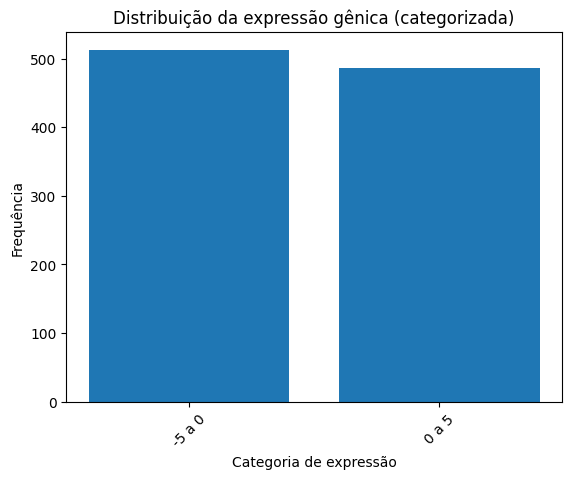

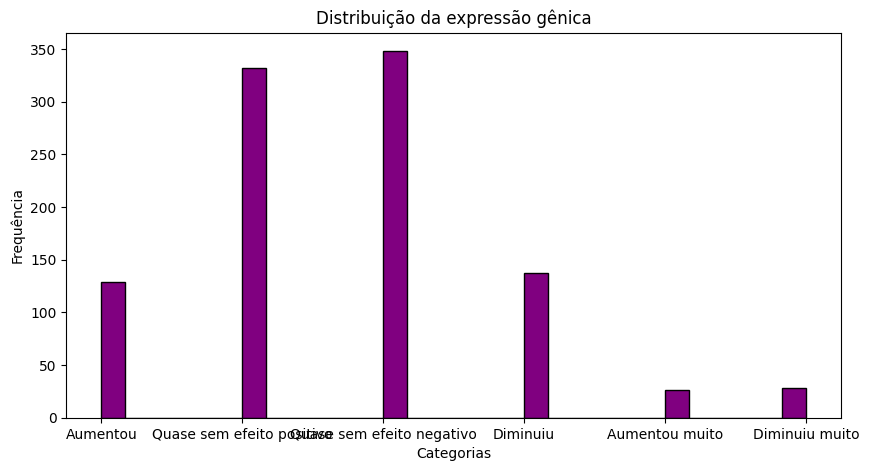

In [ ]:
ordem = ["< -10", "-10 a -5", "-5 a 0", "0 a 5", "5 a 10", "> 10"]
freq_cat = Genes["categoria_expressão"].value_counts().reindex(ordem)
plt.bar(freq_cat.index, freq_cat.values)
plt.title("Distribuição da expressão gênica (categorizada)")
plt.xlabel("Categoria de expressão")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()

categorias = [-np.inf, -2, -1, 0, 1, 2, np.inf]
nomes = ["Diminuiu muito", "Diminuiu", "Quase sem efeito negativo", "Quase sem efeito positivo", "Aumentou", "Aumentou muito"]
Genes["Categorias"] = pd.cut(Genes["expressão_genes"], bins=categorias, labels=nomes)
freq_expressão_categorizada = Genes["Categorias"]

plt.figure(figsize=(10,5))
plt.hist(freq_expressão_categorizada, bins=30, color="purple", edgecolor="black")
plt.title("Distribuição da expressão gênica")
plt.xlabel("Categorias")
plt.ylabel("Frequência")
plt.show()


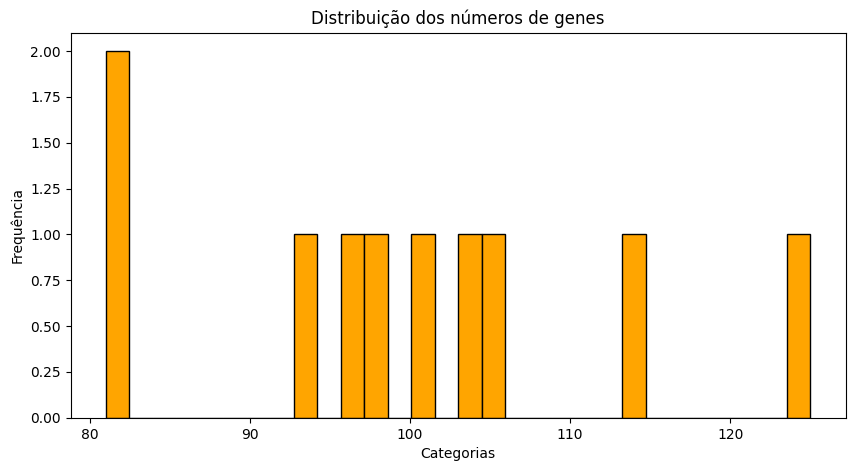

In [41]:
categorias = [-np.inf, 100, 200, 300, 400, 500, 600, 700, 800, 900, np.inf]
nomes = ["0-100", "100-200", "200-300", "300-400", "400-500", "500-600", "600-700", "700-800", "800-900", "900+"]
Genes["categorias"] = pd.cut(Genes["número_de_genes"], bins=categorias, labels=nomes)
freq_numero_genes_categorizada = Genes["categorias"].value_counts()

plt.figure(figsize=(10,5))
plt.hist(freq_numero_genes_categorizada, bins=30, color="orange", edgecolor="black")
plt.title("Distribuição dos números de genes")
plt.xlabel("Categorias")
plt.ylabel("Frequência")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

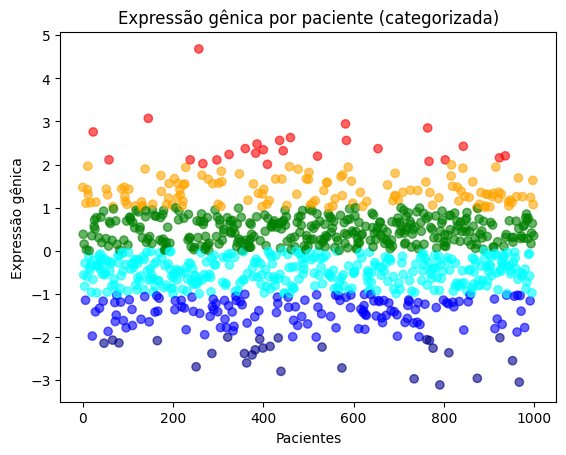

In [37]:
cores_exp = {
    "Diminuiu muito": "darkblue",
    "Diminuiu": "blue",
    "Quase sem efeito negativo": "cyan",
    "Quase sem efeito positivo": "green",
    "Aumentou": "orange",
    "Aumentou muito": "red"
}
cores = Genes["Categorias"].map(cores_exp)
plt.scatter(
    range(len(Genes)),
    Genes["expressão_genes"],
    c=cores,
    alpha=0.6
)
plt.title("Expressão gênica por paciente (categorizada)")
plt.xlabel("Pacientes")
plt.ylabel("Expressão gênica")

plt.show()

In [40]:
print(Genes["categorias"].unique())
print(Genes["categorias"].isna().sum())

['901-1000', '301-400', '201-300', '100-200', '601-700', ..., '801-900', '0-100', '701-800', '401-500', NaN]
Length: 11
Categories (10, object): ['0-100' < '100-200' < '201-300' < '301-400' ... '601-700' < '701-800' < '801-900' < '901-1000']
1


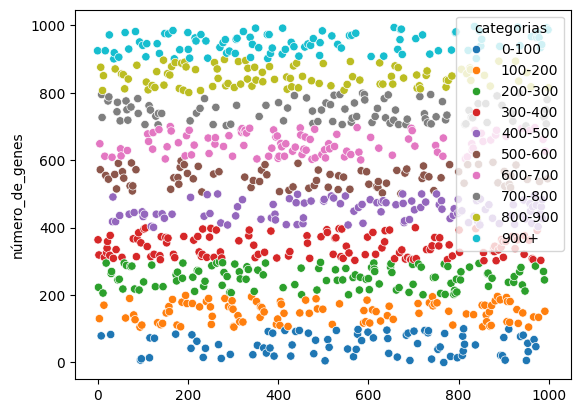

In [ ]:
#Mudei de estratégia, nada tava dando certo
sns.scatterplot(
    data=Genes,
    x=range(len(Genes)),
    y="número_de_genes",
    hue="categorias"
)

plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

Resposta: 1- discreta, 2- contínua, 3- ordinal, 4- contínua, 5- contínua, 6- discreta, 7- contínua, 8- nominal, 9- nominal